# Original Calculation

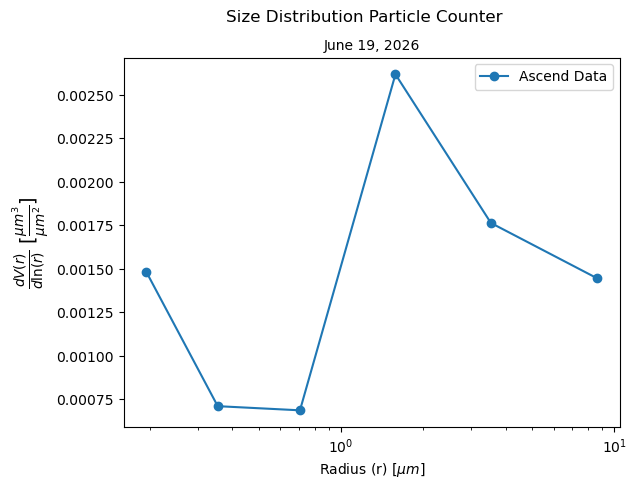

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

particle = pd.read_csv('Particle_Counter_Data_June_19_2026_Flight.csv')
alt = pd.read_csv('AltitudeData06.19.csv')

particle['Time'] = pd.to_datetime(particle['Time'], errors='coerce')
alt['Time'] = pd.to_datetime(alt['time'], format="%m/%d/%y %H:%M", errors='coerce')

particle_strip = particle[(particle['Time']>=alt['Time'].min()) & (particle['Time']<=alt['Time'].max())]

data = pd.merge(particle_strip,alt, on=['Time'], how='left')
df = data[['Time','Size1','Count1 (dM3)','Size2','Count2 (dM3)',
          'Size3','Count3 (dM3)','Size4','Count4 (dM3)','Size5',
          'Count5 (dM3)','Size6','Count6 (dM3)','altitude']].copy()

df['altitude'] = pd.to_numeric(df['altitude'], errors='coerce')
df['altitude'] = df['altitude'].interpolate(method='linear',limit_area='inside')

count_cols = ['Count1 (dM3)','Count2 (dM3)','Count3 (dM3)',
                  'Count4 (dM3)','Count5 (dM3)','Count6 (dM3)']

D_edges = np.array([df['Size1'][0],df['Size2'][0],df['Size3'][0],
                    df['Size4'][0],df['Size5'][0],df['Size6'][0],30],dtype=float)
r_edges = D_edges/2

r_mid = np.sqrt(r_edges[:-1]*r_edges[1:])
dlnr = np.log(r_edges[1:]/r_edges[:-1])

dN_dM3 = df[count_cols].to_numpy(dtype=float)
dVdlnr_local = (4*np.pi/3)*(r_mid**3)*(dN_dM3/dlnr)

for i,r in enumerate(r_mid):
    df[f'dVdlnr{i+1}'] = dVdlnr_local[:,i]

idx_max_alt = df['altitude'].idxmax()
df_ascent = df.loc[:idx_max_alt].copy()

# Calculating Ascending Data
z = np.array(df_ascent['altitude'])
dz = np.abs(np.diff(z)) # calculate Δz
dVdlnr1 = np.array(df_ascent['dVdlnr1'])
dVdlnr2 = np.array(df_ascent['dVdlnr2'])
dVdlnr3 = np.array(df_ascent['dVdlnr3'])
dVdlnr4 = np.array(df_ascent['dVdlnr4'])
dVdlnr5 = np.array(df_ascent['dVdlnr5'])
dVdlnr6 = np.array(df_ascent['dVdlnr6'])

# Left Riemann Sum and Convert to um^2
p1 = sum(dVdlnr1[:-1]*dz)*(1e-6)**2
p2 = sum(dVdlnr2[:-1]*dz)*(1e-6)**2
p3 = sum(dVdlnr3[:-1]*dz)*(1e-6)**2
p4 = sum(dVdlnr4[:-1]*dz)*(1e-6)**2
p5 = sum(dVdlnr5[:-1]*dz)*(1e-6)**2
p6 = sum(dVdlnr6[:-1]*dz)*(1e-6)**2

py = np.array([p1,p2,p3,p4,p5,p6],dtype=float)

plt.plot(r_mid,py,'o-',label='Ascend Data')
plt.xscale('log')
plt.ylabel(r'$\frac{dV(r)}{d\ln(r)}$ [$\frac{\mu m^3}{\mu m^2}$]', fontsize=14)
plt.xlabel(r'Radius (r) [$\mu m$]')
plt.suptitle("Size Distribution Particle Counter")
plt.title("June 19, 2026", fontsize=10)
plt.legend()
plt.show()

# Experimenting with Descending Data and Round Trip

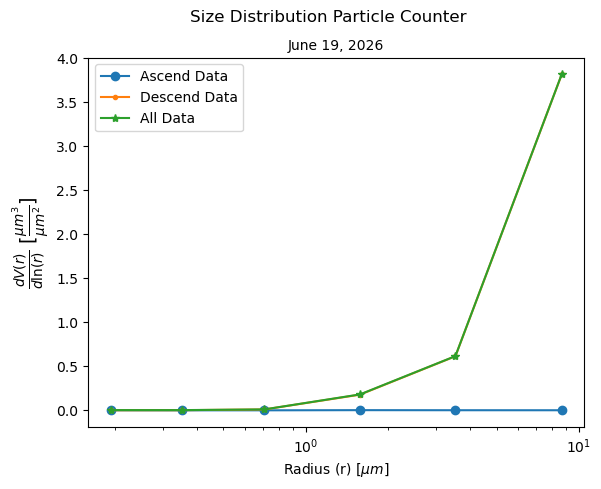

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

particle = pd.read_csv('Particle_Counter_Data_June_19_2026_Flight.csv')
alt = pd.read_csv('AltitudeData06.19.csv')

particle['Time'] = pd.to_datetime(particle['Time'], errors='coerce')
alt['Time'] = pd.to_datetime(alt['time'], format="%m/%d/%y %H:%M", errors='coerce')

particle_strip = particle[(particle['Time']>=alt['Time'].min()) & (particle['Time']<=alt['Time'].max())]

data = pd.merge(particle_strip,alt, on=['Time'], how='left')
df = data[['Time','Size1','Count1 (dM3)','Size2','Count2 (dM3)',
          'Size3','Count3 (dM3)','Size4','Count4 (dM3)','Size5',
          'Count5 (dM3)','Size6','Count6 (dM3)','altitude']].copy()

df['altitude'] = pd.to_numeric(df['altitude'], errors='coerce')
df['altitude'] = df['altitude'].interpolate(method='linear',limit_area='inside')

count_cols = ['Count1 (dM3)','Count2 (dM3)','Count3 (dM3)',
                  'Count4 (dM3)','Count5 (dM3)','Count6 (dM3)']

D_edges = np.array([df['Size1'][0],df['Size2'][0],df['Size3'][0],
                    df['Size4'][0],df['Size5'][0],df['Size6'][0],30],dtype=float)
r_edges = D_edges/2

r_mid = np.sqrt(r_edges[:-1]*r_edges[1:])
dlnr = np.log(r_edges[1:]/r_edges[:-1])

dN_dM3 = df[count_cols].to_numpy(dtype=float)
dVdlnr_local = (4*np.pi/3)*(r_mid**3)*(dN_dM3/dlnr)

for i,r in enumerate(r_mid):
    df[f'dVdlnr{i+1}'] = dVdlnr_local[:,i]

idx_max_alt = df['altitude'].idxmax()
df_ascent = df.loc[:idx_max_alt].copy()
df_descent = df.loc[idx_max_alt:].copy()


# Calculating Ascending Data
z = np.array(df_ascent['altitude'])
dz = np.abs(np.diff(z)) # calculate Δz
dVdlnr1 = np.array(df_ascent['dVdlnr1'])
dVdlnr2 = np.array(df_ascent['dVdlnr2'])
dVdlnr3 = np.array(df_ascent['dVdlnr3'])
dVdlnr4 = np.array(df_ascent['dVdlnr4'])
dVdlnr5 = np.array(df_ascent['dVdlnr5'])
dVdlnr6 = np.array(df_ascent['dVdlnr6'])

# Left Riemann Sum and Convert to um^2
p1 = sum(dVdlnr1[:-1]*dz)*(1e-6)**2
p2 = sum(dVdlnr2[:-1]*dz)*(1e-6)**2
p3 = sum(dVdlnr3[:-1]*dz)*(1e-6)**2
p4 = sum(dVdlnr4[:-1]*dz)*(1e-6)**2
p5 = sum(dVdlnr5[:-1]*dz)*(1e-6)**2
p6 = sum(dVdlnr6[:-1]*dz)*(1e-6)**2

py = np.array([p1,p2,p3,p4,p5,p6],dtype=float)

# Calculating Descending Data
zd = np.array(df_descent['altitude'])
dzd = np.abs(np.diff(zd)) # calculate Δz
dVdlnr1d = np.array(df_descent['dVdlnr1'])
dVdlnr2d = np.array(df_descent['dVdlnr2'])
dVdlnr3d = np.array(df_descent['dVdlnr3'])
dVdlnr4d = np.array(df_descent['dVdlnr4'])
dVdlnr5d = np.array(df_descent['dVdlnr5'])
dVdlnr6d = np.array(df_descent['dVdlnr6'])

# Left Riemann Sum and Convert to um^2
p1d = sum(dVdlnr1d[:-1]*dzd)*(1e-6)**2
p2d = sum(dVdlnr2d[:-1]*dzd)*(1e-6)**2
p3d = sum(dVdlnr3d[:-1]*dzd)*(1e-6)**2
p4d = sum(dVdlnr4d[:-1]*dzd)*(1e-6)**2
p5d = sum(dVdlnr5d[:-1]*dzd)*(1e-6)**2
p6d = sum(dVdlnr6d[:-1]*dzd)*(1e-6)**2

pyd = np.array([p1d,p2d,p3d,p4d,p5d,p6d],dtype=float)

# Calculating Round Trip
zr = np.array(df['altitude'])
dzr = np.abs(np.diff(zr)) # calculate Δz
dVdlnr1r = np.array(df['dVdlnr1'])
dVdlnr2r = np.array(df['dVdlnr2'])
dVdlnr3r = np.array(df['dVdlnr3'])
dVdlnr4r = np.array(df['dVdlnr4'])
dVdlnr5r = np.array(df['dVdlnr5'])
dVdlnr6r = np.array(df['dVdlnr6'])

# Left Riemann Sum and Convert to um^2
p1r = sum(dVdlnr1r[:-1]*dzr)*(1e-6)**2
p2r = sum(dVdlnr2r[:-1]*dzr)*(1e-6)**2
p3r = sum(dVdlnr3r[:-1]*dzr)*(1e-6)**2
p4r = sum(dVdlnr4r[:-1]*dzr)*(1e-6)**2
p5r = sum(dVdlnr5r[:-1]*dzr)*(1e-6)**2
p6r = sum(dVdlnr6r[:-1]*dzr)*(1e-6)**2

pyr = np.array([p1r,p2r,p3r,p4r,p5r,p6r],dtype=float)

plt.plot(r_mid,py,'o-',label='Ascend Data')
plt.plot(r_mid,pyd,'.-',label='Descend Data')
plt.plot(r_mid,pyr,'*-',label='All Data')
plt.xscale('log')
plt.ylabel(r'$\frac{dV(r)}{d\ln(r)}$ [$\frac{\mu m^3}{\mu m^2}$]', fontsize=14)
plt.xlabel(r'Radius (r) [$\mu m$]')
plt.suptitle("Size Distribution Particle Counter")
plt.title("June 19, 2026", fontsize=10)
plt.legend()
plt.show()

# Experimenting with Uncertainty

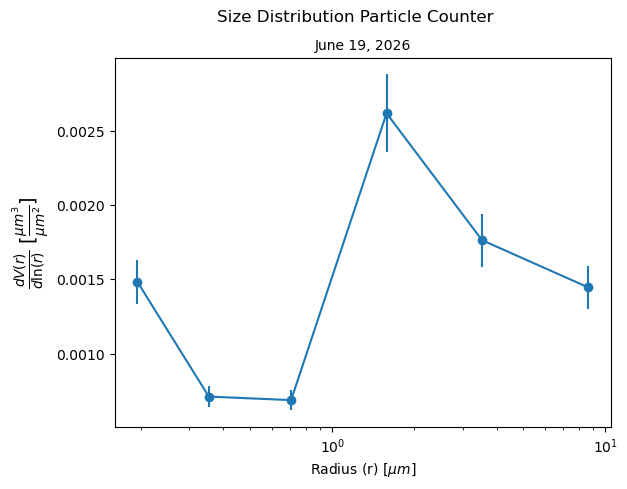

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

particle = pd.read_csv('Particle_Counter_Data_June_19_2026_Flight.csv')
alt = pd.read_csv('AltitudeData06.19.csv')

particle['Time'] = pd.to_datetime(particle['Time'], errors='coerce')
alt['Time'] = pd.to_datetime(alt['time'], format="%m/%d/%y %H:%M", errors='coerce')

particle_strip = particle[(particle['Time']>=alt['Time'].min()) & (particle['Time']<=alt['Time'].max())]

data = pd.merge(particle_strip,alt, on=['Time'], how='left')
df = data[['Time','Size1','Count1 (dM3)','Size2','Count2 (dM3)',
          'Size3','Count3 (dM3)','Size4','Count4 (dM3)','Size5',
          'Count5 (dM3)','Size6','Count6 (dM3)','altitude']].copy()

df['altitude_raw'] = pd.to_numeric(df['altitude'], errors='coerce')
df['altitude'] = df['altitude'].interpolate(method='linear',limit_area='inside')

count_cols = ['Count1 (dM3)','Count2 (dM3)','Count3 (dM3)',
                  'Count4 (dM3)','Count5 (dM3)','Count6 (dM3)']

D_edges = np.array([df['Size1'][0],df['Size2'][0],df['Size3'][0],
                    df['Size4'][0],df['Size5'][0],df['Size6'][0],30],dtype=float)
r_edges = D_edges/2

r_mid = np.sqrt(r_edges[:-1]*r_edges[1:])
dlnr = np.log(r_edges[1:]/r_edges[:-1])

dN_dM3 = df[count_cols].to_numpy(dtype=float)
dVdlnr_local = (4*np.pi/3)*(r_mid**3)*(dN_dM3/dlnr)

for i,r in enumerate(r_mid):
    df[f'dVdlnr{i+1}'] = dVdlnr_local[:,i]

idx_max_alt = df['altitude'].idxmax()
df_ascent = df.loc[:idx_max_alt].copy()

# Calculating Ascending Data
z = np.array(df_ascent['altitude'])
dz = np.abs(np.diff(z)) # calculate Δz
dVdlnr1 = np.array(df_ascent['dVdlnr1'])
dVdlnr2 = np.array(df_ascent['dVdlnr2'])
dVdlnr3 = np.array(df_ascent['dVdlnr3'])
dVdlnr4 = np.array(df_ascent['dVdlnr4'])
dVdlnr5 = np.array(df_ascent['dVdlnr5'])
dVdlnr6 = np.array(df_ascent['dVdlnr6'])

# Left Riemann Sum and Convert to um^2
p1 = sum(dVdlnr1[:-1]*dz)*(1e-6)**2
p2 = sum(dVdlnr2[:-1]*dz)*(1e-6)**2
p3 = sum(dVdlnr3[:-1]*dz)*(1e-6)**2
p4 = sum(dVdlnr4[:-1]*dz)*(1e-6)**2
p5 = sum(dVdlnr5[:-1]*dz)*(1e-6)**2
p6 = sum(dVdlnr6[:-1]*dz)*(1e-6)**2

py = np.array([p1,p2,p3,p4,p5,p6],dtype=float)

# Calculating Uncertainty
σz = 5.0  # Assuming the altimeter sensor accuracy is about 5m (clarify pending)
particle_rel = 0.1  # 10% Uncertainty from the PC

dV_for_sum = np.column_stack([dVdlnr1[:-1],dVdlnr2[:-1],dVdlnr3[:-1],
                              dVdlnr4[:-1],dVdlnr5[:-1],dVdlnr6[:-1]])

# Particle Counter Uncertainty
σ_py_pc = particle_rel * np.abs(py)

# Altitude dz Uncertainty
σ_z = np.full_like(z,σz,dtype=float)
σ_dz = np.sqrt(σ_z[:-1]**2 + σ_z[1:]**2)
σ_py_alt = np.sqrt(np.sum((dV_for_sum * σ_dz[:,None])**2,axis=0))*1e-12

# Total Uncertainty
σpy = np.sqrt(σ_py_pc**2 + σ_py_alt**2)

plt.errorbar(r_mid,py, yerr=σpy,fmt='o-')
plt.xscale('log')
plt.ylabel(r'$\frac{dV(r)}{d\ln(r)}$ [$\frac{\mu m^3}{\mu m^2}$]', fontsize=14)
plt.xlabel(r'Radius (r) [$\mu m$]')
plt.suptitle("Size Distribution Particle Counter")
plt.title("June 19, 2026", fontsize=10)
plt.show()

# Balloon is actually landed around 5:48 pm.

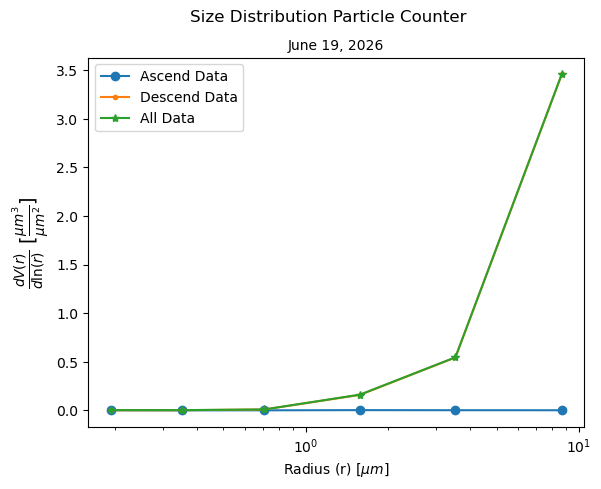

In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

particle = pd.read_csv('Particle_Counter_Data_June_19_2026_Flight.csv')
alt = pd.read_csv('AltitudeData06.19.csv')

particle['Time'] = pd.to_datetime(particle['Time'], errors='coerce')
alt['Time'] = pd.to_datetime(alt['time'], format="%m/%d/%y %H:%M", errors='coerce')

particle_strip = particle[(particle['Time']>=alt['Time'].min()) & (particle['Time']<=pd.Timestamp('2026-06-19 17:48:00'))]

data = pd.merge(particle_strip,alt, on=['Time'], how='left')
df = data[['Time','Size1','Count1 (dM3)','Size2','Count2 (dM3)',
          'Size3','Count3 (dM3)','Size4','Count4 (dM3)','Size5',
          'Count5 (dM3)','Size6','Count6 (dM3)','altitude']].copy()

df['altitude'] = pd.to_numeric(df['altitude'], errors='coerce')
df['altitude'] = df['altitude'].interpolate(method='linear',limit_area='inside')

count_cols = ['Count1 (dM3)','Count2 (dM3)','Count3 (dM3)',
                  'Count4 (dM3)','Count5 (dM3)','Count6 (dM3)']

D_edges = np.array([df['Size1'][0],df['Size2'][0],df['Size3'][0],
                    df['Size4'][0],df['Size5'][0],df['Size6'][0],30],dtype=float)
r_edges = D_edges/2

r_mid = np.sqrt(r_edges[:-1]*r_edges[1:])
dlnr = np.log(r_edges[1:]/r_edges[:-1])

dN_dM3 = df[count_cols].to_numpy(dtype=float)
dVdlnr_local = (4*np.pi/3)*(r_mid**3)*(dN_dM3/dlnr)

for i,r in enumerate(r_mid):
    df[f'dVdlnr{i+1}'] = dVdlnr_local[:,i]

idx_max_alt = df['altitude'].idxmax()
df_ascent = df.loc[:idx_max_alt].copy()
df_descent = df.loc[idx_max_alt:].copy()

# Calculating Ascending Data
z = np.array(df_ascent['altitude'])
dz = np.abs(np.diff(z)) # calculate Δz
dVdlnr1 = np.array(df_ascent['dVdlnr1'])
dVdlnr2 = np.array(df_ascent['dVdlnr2'])
dVdlnr3 = np.array(df_ascent['dVdlnr3'])
dVdlnr4 = np.array(df_ascent['dVdlnr4'])
dVdlnr5 = np.array(df_ascent['dVdlnr5'])
dVdlnr6 = np.array(df_ascent['dVdlnr6'])

# Left Riemann Sum and Convert to um^2
p1 = sum(dVdlnr1[:-1]*dz)*(1e-6)**2
p2 = sum(dVdlnr2[:-1]*dz)*(1e-6)**2
p3 = sum(dVdlnr3[:-1]*dz)*(1e-6)**2
p4 = sum(dVdlnr4[:-1]*dz)*(1e-6)**2
p5 = sum(dVdlnr5[:-1]*dz)*(1e-6)**2
p6 = sum(dVdlnr6[:-1]*dz)*(1e-6)**2

py = np.array([p1,p2,p3,p4,p5,p6],dtype=float)

# Calculating Descending Data
zd = np.array(df_descent['altitude'])
dzd = np.abs(np.diff(zd)) # calculate Δz
dVdlnr1d = np.array(df_descent['dVdlnr1'])
dVdlnr2d = np.array(df_descent['dVdlnr2'])
dVdlnr3d = np.array(df_descent['dVdlnr3'])
dVdlnr4d = np.array(df_descent['dVdlnr4'])
dVdlnr5d = np.array(df_descent['dVdlnr5'])
dVdlnr6d = np.array(df_descent['dVdlnr6'])

# Left Riemann Sum and Convert to um^2
p1d = sum(dVdlnr1d[:-1]*dzd)*(1e-6)**2
p2d = sum(dVdlnr2d[:-1]*dzd)*(1e-6)**2
p3d = sum(dVdlnr3d[:-1]*dzd)*(1e-6)**2
p4d = sum(dVdlnr4d[:-1]*dzd)*(1e-6)**2
p5d = sum(dVdlnr5d[:-1]*dzd)*(1e-6)**2
p6d = sum(dVdlnr6d[:-1]*dzd)*(1e-6)**2

pyd = np.array([p1d,p2d,p3d,p4d,p5d,p6d],dtype=float)

# Calculating Round Trip
zr = np.array(df['altitude'])
dzr = np.abs(np.diff(zr)) # calculate Δz
dVdlnr1r = np.array(df['dVdlnr1'])
dVdlnr2r = np.array(df['dVdlnr2'])
dVdlnr3r = np.array(df['dVdlnr3'])
dVdlnr4r = np.array(df['dVdlnr4'])
dVdlnr5r = np.array(df['dVdlnr5'])
dVdlnr6r = np.array(df['dVdlnr6'])

# Left Riemann Sum and Convert to um^2
p1r = sum(dVdlnr1r[:-1]*dzr)*(1e-6)**2
p2r = sum(dVdlnr2r[:-1]*dzr)*(1e-6)**2
p3r = sum(dVdlnr3r[:-1]*dzr)*(1e-6)**2
p4r = sum(dVdlnr4r[:-1]*dzr)*(1e-6)**2
p5r = sum(dVdlnr5r[:-1]*dzr)*(1e-6)**2
p6r = sum(dVdlnr6r[:-1]*dzr)*(1e-6)**2

pyr = np.array([p1r,p2r,p3r,p4r,p5r,p6r],dtype=float)

plt.plot(r_mid,py,'o-',label='Ascend Data')
plt.plot(r_mid,pyd,'.-',label='Descend Data')
plt.plot(r_mid,pyr,'*-',label='All Data')
plt.xscale('log')
plt.ylabel(r'$\frac{dV(r)}{d\ln(r)}$ [$\frac{\mu m^3}{\mu m^2}$]', fontsize=14)
plt.xlabel(r'Radius (r) [$\mu m$]')
plt.suptitle("Size Distribution Particle Counter")
plt.title("June 19, 2026", fontsize=10)
plt.legend()
plt.show()

#### I was analyzing the particle data and I found out that the particle count increase instantly right after the maximum height. This could encounter that the particle counter is sensing the contaminnation or fragment from the balloon burst. The countt is extremely high and inconsistent with the previous data count. Thus, I propose that the descending data is therefore unreliable for the analysis. We can only use the ascending data count for the analysis.

#### Additionally, the air flow is less stable when descending due to the inconsistent descending speed. Thus, it further justify that we should only consider the ascending data for the analysis.